# Optimal Transport via Hypernetworks

To use hypernetworks for uncertainty quantification in optimal transport, we will use input convex neural networks (ICNN) [refs](https://arxiv.org/pdf/1908.10962). 

The general premise is to use an ICNN as the base model, wrap it in a hypernetwork and then perform training as typically done. Each sample can then generate a unique transport function. Additionally, the hypernetwork makes it easy to perform modifications to the weights, using the theta transform (positive weights.)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from hnet.models.HyperNet import HyperNet

%load_ext autoreload
%autoreload 2

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using {device}")

Using cuda


## 2D Two-Gaussian Dataset

Source $P \sim \mathcal{N}(\mu_P, \Sigma_P)$ and target $Q \sim \mathcal{N}(\mu_Q, \Sigma_Q)$. For 2D Gaussians with diagonal covariances, the $W_2$ optimal transport map is $T(x) = \mu_Q + \text{diag}(\sigma_Q / \sigma_P)(x - \mu_P)$.

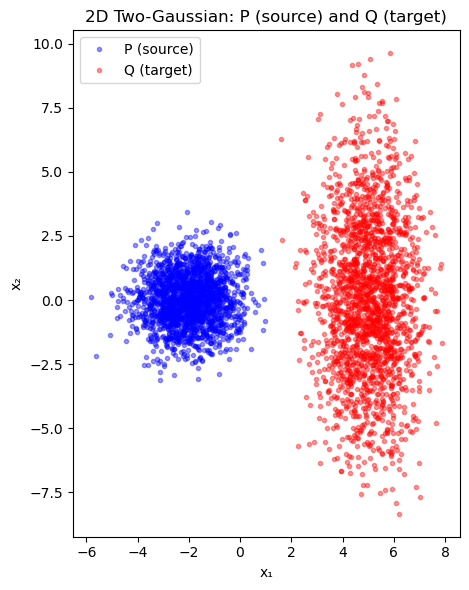

In [2]:
torch.manual_seed(42)
n_samples = 2000

mu_P = torch.tensor([-2.0, 0.0])
sigma_P = torch.tensor([1.0, 1.0])
mu_Q = torch.tensor([5.0, 0.0])
sigma_Q = torch.tensor([1.0, 3.0])

P = torch.randn(n_samples, 2) * sigma_P + mu_P
Q = torch.randn(n_samples, 2) * sigma_Q + mu_Q

def optimal_transport_map(x):
    return mu_Q + (sigma_Q / sigma_P) * (x - mu_P)

Q_paired = optimal_transport_map(P)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(P[:, 0].numpy(), P[:, 1].numpy(), 'b.', alpha=0.4, label='P (source)')
ax.plot(Q[:, 0].numpy(), Q[:, 1].numpy(), 'r.', alpha=0.4, label='Q (target)')
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.legend()
ax.set_aspect('equal')
ax.set_title('2D Two-Gaussian: P (source) and Q (target)')
plt.tight_layout()
plt.show()

In [3]:
import time

from scipy.stats.distributions import truncexpon
import torch
import torch.nn.functional as F
from torch import nn, autograd
import numpy as np


def to_numpy(tensor):
    return tensor.to("cpu").detach().numpy()


def to_torch(arr):
    return torch.tensor(arr, device=device, requires_grad=True)


class PositiveLinear(nn.Linear):
    """Linear layer whose weights are passed through softplus to guarantee positivity."""
    def __init__(self, *args, **kwargs): 
        super().__init__(*args, **kwargs)
        #self.f = torch.nn.Softplus()
        #self.scalar = 2/self.in_features # hnet has initial values, assume roughly normal
        self.f = torch.nn.ReLU()

    def forward(self, x):
        W = self.f(self.weight) #* self.scalar
        return F.linear(x, W, self.bias)


class ICNN(torch.nn.Module):
    """Input Convex Neural Network"""
    # see Fig 2: https://arxiv.org/pdf/1908.10962

    def __init__(self, dim=2, dimh=64, num_hidden_layers=4):
        super().__init__()

        # most be non-negaative
        Ws = []
        for _ in range(num_hidden_layers - 1):
            Ws.append(PositiveLinear(dimh, dimh, bias=False))
        Ws.append(PositiveLinear(dimh, 1, bias=False))
        self.Ws = torch.nn.ModuleList(Ws)

        # does nto have to be non-negative
        self.A0 = nn.Linear(dim, dimh, bias=True)
        As = []
        for _ in range(num_hidden_layers - 1):
            As.append(nn.Linear(dim, dimh, bias=True))
        As.append(nn.Linear(dim, 1, bias=True))
        self.As = torch.nn.ModuleList(As)
        
        self.nonlin = nn.Softplus() # must be convex 
        #self.nonlin = nn.Sigmoid() # must be convex 
        #self.nonlin = nn.ELU() # must be convex 

    def forward(self, x):
        
        z = self.nonlin( self.A0(x) )

        for W,A in zip(self.Ws, self.As): 
            z = self.nonlin(W(z) + A(x)) 

        return z


def transport(model, x):
    return autograd.grad(torch.sum(model(x)), x)[0]


def y_to_x(g, y):
        return transport(g, y)

def x_to_y(f, x):
    return transport(f, x)


In [4]:
def J_f_g(f, g, x, y): 
    '''
    Eq (9) from the paper: https://arxiv.org/pdf/1908.10962
    '''
    x = x.detach() 
    y = y.detach() 
    x.requires_grad = True 
    y.requires_grad = True 

    fx = f(x)
    gy = g(y)

    grad_gy = autograd.grad(gy.sum(), y, retain_graph=True, create_graph=True)[0]
    f_grad_gy = f(grad_gy)
    y_dot_grad_gy = (y*grad_gy).sum(-1)

    J = torch.mean(f_grad_gy - y_dot_grad_gy - fx)
    return J


from torch.func import jacrev, vmap, functional_call
def J_f_g2(f, g, x, y, n_samples=10): 
    '''
    Eq (9) from the paper: https://arxiv.org/pdf/1908.10962 ; vectorized for use with hypernets 
    Each sample n uses the SAME (f_n, g_n) pair for all terms.
    # Use jacrev + functional_call per https://discuss.pytorch.org/t/vmap-over-autograd-grad-of-a-nn-module/179038/2

    '''
    x = x.detach() 
    y = y.detach() 
    x.requires_grad = True 
    y.requires_grad = True 

    z = f._sample_z(n_samples).to(x.device)

    def single_loss(z_n, x, y):
        f_params = f.sample(z=z_n)
        g_params = g.sample(z=z_n)

        fx_n = functional_call(f.model, f_params, x)                  # (B, 1)

        def g_call(y):
            return functional_call(g.model, g_params, y).sum()
        grad_gy_n = jacrev(g_call)(y).squeeze(0)                      # (B, 2)

        f_grad_gy_n = functional_call(f.model, f_params, grad_gy_n)   # (B, 1)
        y_dot_grad_gy_n = (y * grad_gy_n).sum(-1, keepdim=True)       # (B, 1)

        return (f_grad_gy_n - y_dot_grad_gy_n - fx_n).mean()

    J = vmap(single_loss, in_dims=(0, None, None))(z, x, y).mean()
    
    return J

    
def sample_x(P, B=512): 
    xx = P[torch.randperm(n_samples)[:B]].to(device).detach()
    xx.requires_grad = True
    return xx 

def sample_y(Q, B=512): 
    yy = Q[torch.randperm(n_samples)[:B]].to(device).detach()
    yy.requires_grad = True
    return yy

def mmd_rbf(X, Y, bandwidth=None):
    """Unbiased MMD² with RBF kernel."""
    if bandwidth is None:
        dists = np.sqrt(np.sum((Y[:, None] - Y[None, :]) ** 2, axis=-1))
        bandwidth = float(np.median(dists[np.triu_indices(len(Y), k=1)]))
    def rbf(A, B):
        return np.exp(-np.sum((A[:, None] - B[None, :]) ** 2, axis=-1) / (2 * bandwidth ** 2))
    Kxx, Kyy, Kxy = rbf(X, X), rbf(Y, Y), rbf(X, Y)
    np.fill_diagonal(Kxx, 0); np.fill_diagonal(Kyy, 0)
    n, m = len(X), len(Y)
    return float(Kxx.sum() / (n*(n-1)) + Kyy.sum() / (m*(m-1)) - 2*Kxy.mean())


In [ ]:
f_base = ICNN(dim=2, dimh=256, num_hidden_layers=2).to(device)
g_base = ICNN(dim=2, dimh=256, num_hidden_layers=2).to(device)

pz = 'bernoulli'

f = HyperNet(f_base, stochastic_channels = 64, width=128, pz=pz, bias=True).to(device)
g = HyperNet(g_base, stochastic_channels = 64, width=128, pz=pz, bias=True).to(device)

optim_f = torch.optim.AdamW(f.parameters(), lr=1e-4, weight_decay=1e-6)
optim_g = torch.optim.AdamW(g.parameters(), lr=1e-4, weight_decay=1e-6)

print(f"f total: {sum(p.numel() for p in f.parameters()):,}")
print(f"g total: {sum(p.numel() for p in g.parameters()):,}")

In [101]:
B = 256
iters = 250 
g_steps = 3
print_every = 25
n_samples = 100
k_mmd = 1

history = {'f_loss': [], 'g_loss': [], 'mmd': []}

for iter in range(1, iters + 1):

    x = sample_x(P, B) 

    for ii in range(g_steps): 
        optim_g.zero_grad() 
        y = sample_y(Q, B)
        g_loss = J_f_g2(f,g,x,y, n_samples=n_samples) # minimize (9)
        g_loss.backward()
        optim_g.step()

    optim_f.zero_grad()
    f_loss = -J_f_g2(f,g,x,y, n_samples=n_samples) # maximize (9)
    f_loss.backward()
    optim_f.step()

    # eval
    mmd = 0
    for _ in range(k_mmd): 
        sd = f.sample() # sample a function
        f_base.load_state_dict(sd)
        yhat = x_to_y(f_base, P.to(device).requires_grad_(True))
        mmd += mmd_rbf(Q.detach().cpu().numpy(), yhat.detach().cpu().numpy())
    mmd /= k_mmd

    history['f_loss'].append(f_loss.item())
    history['g_loss'].append(g_loss.item())
    history['mmd'].append(mmd)

    if (iter % print_every) == 0: 
        print(f'Iteration {iter}, f_loss {f_loss.item():.2f}, g_loss {g_loss.item():.2f} mmd: {np.mean(history['mmd'][-print_every:]):.4f}')
        

Iteration 25, f_loss -4.53, g_loss 4.81 mmd: 0.3881
Iteration 50, f_loss -6.13, g_loss 6.30 mmd: 0.0894
Iteration 75, f_loss -6.18, g_loss 6.21 mmd: 0.0732
Iteration 100, f_loss -6.41, g_loss 6.24 mmd: 0.0650
Iteration 125, f_loss -6.35, g_loss 6.40 mmd: 0.0491
Iteration 150, f_loss -6.38, g_loss 6.46 mmd: 0.0574
Iteration 175, f_loss -6.42, g_loss 6.47 mmd: 0.0381
Iteration 200, f_loss -6.48, g_loss 6.50 mmd: 0.0258
Iteration 225, f_loss -6.61, g_loss 6.52 mmd: 0.0424
Iteration 250, f_loss -6.55, g_loss 6.57 mmd: 0.0318


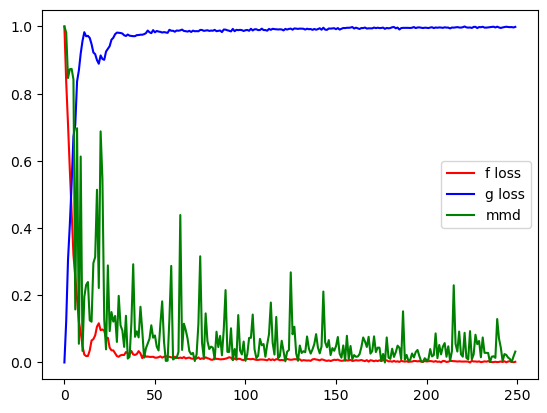

In [102]:
def scale(x):
    x = np.array(x) 

    x = (x - min(x)) 
    x /= max(x)
    return x 

plt.figure() 
plt.plot(scale(history['f_loss']) , 'r-', label='f loss')
plt.plot(scale(history['g_loss']), 'b-', label='g loss')
plt.plot(scale(history['mmd']), 'g-', label='mmd')
plt.legend()
plt.show() 

## Predicted Transport Maps

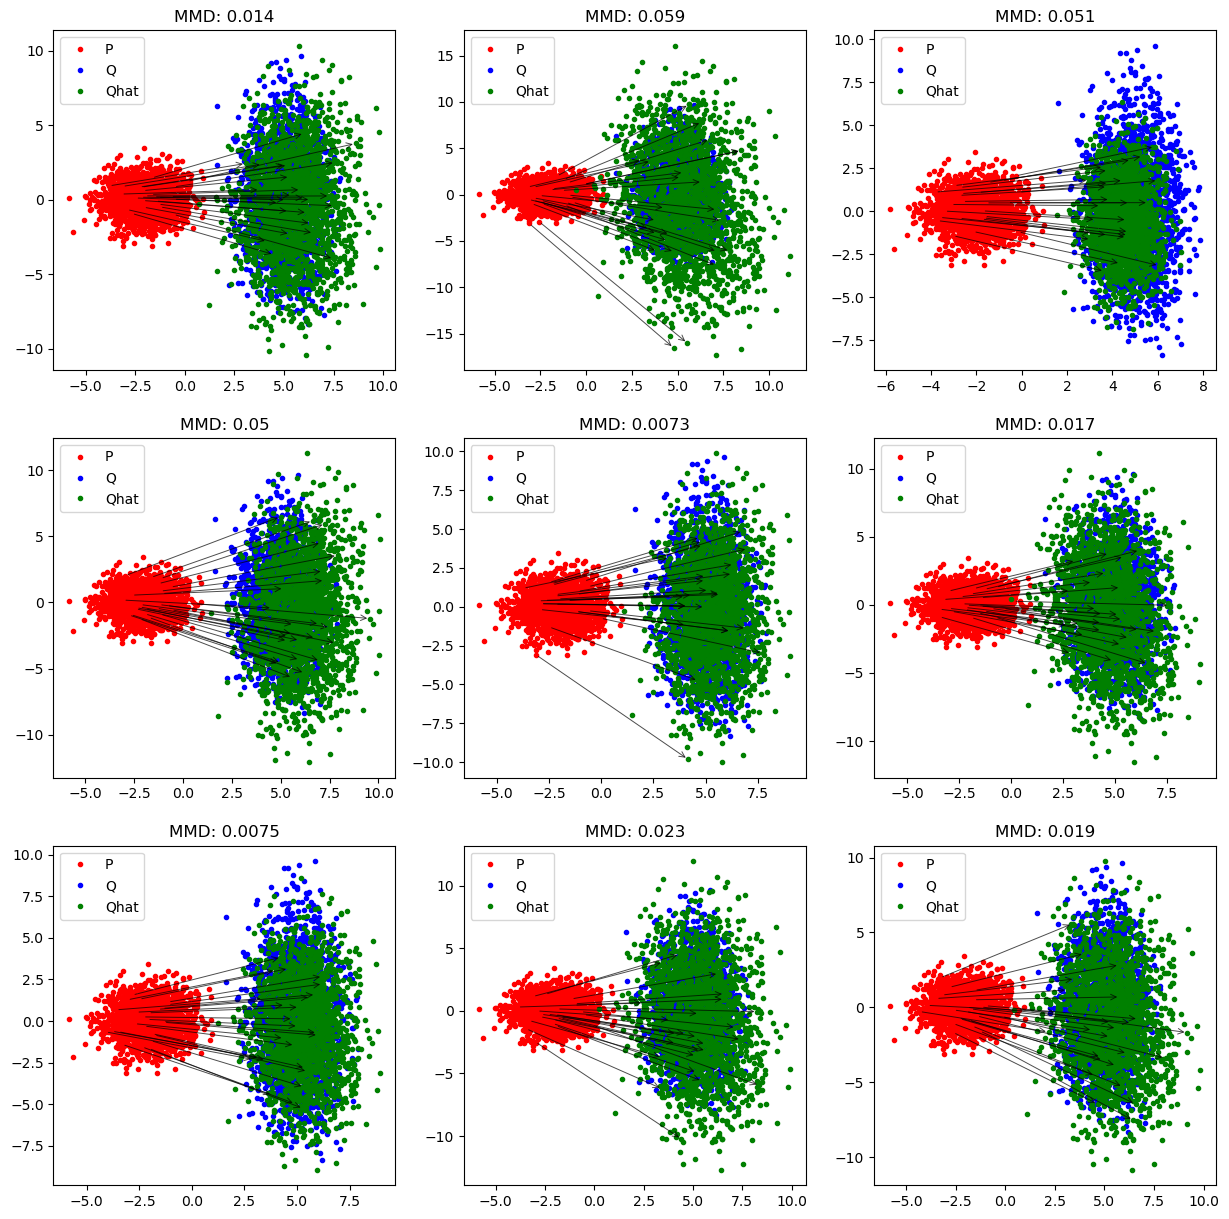

In [103]:

fig,axes = plt.subplots(3,3, figsize=(15,15))

for ax in axes.flat: 

    # sample f,g 
    f_state_dict = f.sample() 
    f_base.load_state_dict(f_state_dict)
    Qhat = x_to_y(f_base, P.cuda().requires_grad_(True)).detach().cpu().numpy()

    mmd = mmd_rbf(Q.detach().cpu().numpy(), Qhat)

    ax.plot(P[:, 0], P[:, 1], 'r.', label='P')
    ax.plot(Q[:, 0], Q[:, 1], 'b.', label='Q')
    ax.plot(Qhat[:, 0], Qhat[:, 1], 'g.', label='Qhat')
    ax.set_title(f'MMD: {mmd:.2}')

    N_show = 25 
    for i in np.random.randint(0, len(P), size=(N_show,)): 
        
        ax.annotate('', xy=Qhat[i], xytext=P[i],
                    arrowprops=dict(arrowstyle='->', color='k', alpha=0.7, lw=0.7))

    ax.legend()
plt.show()

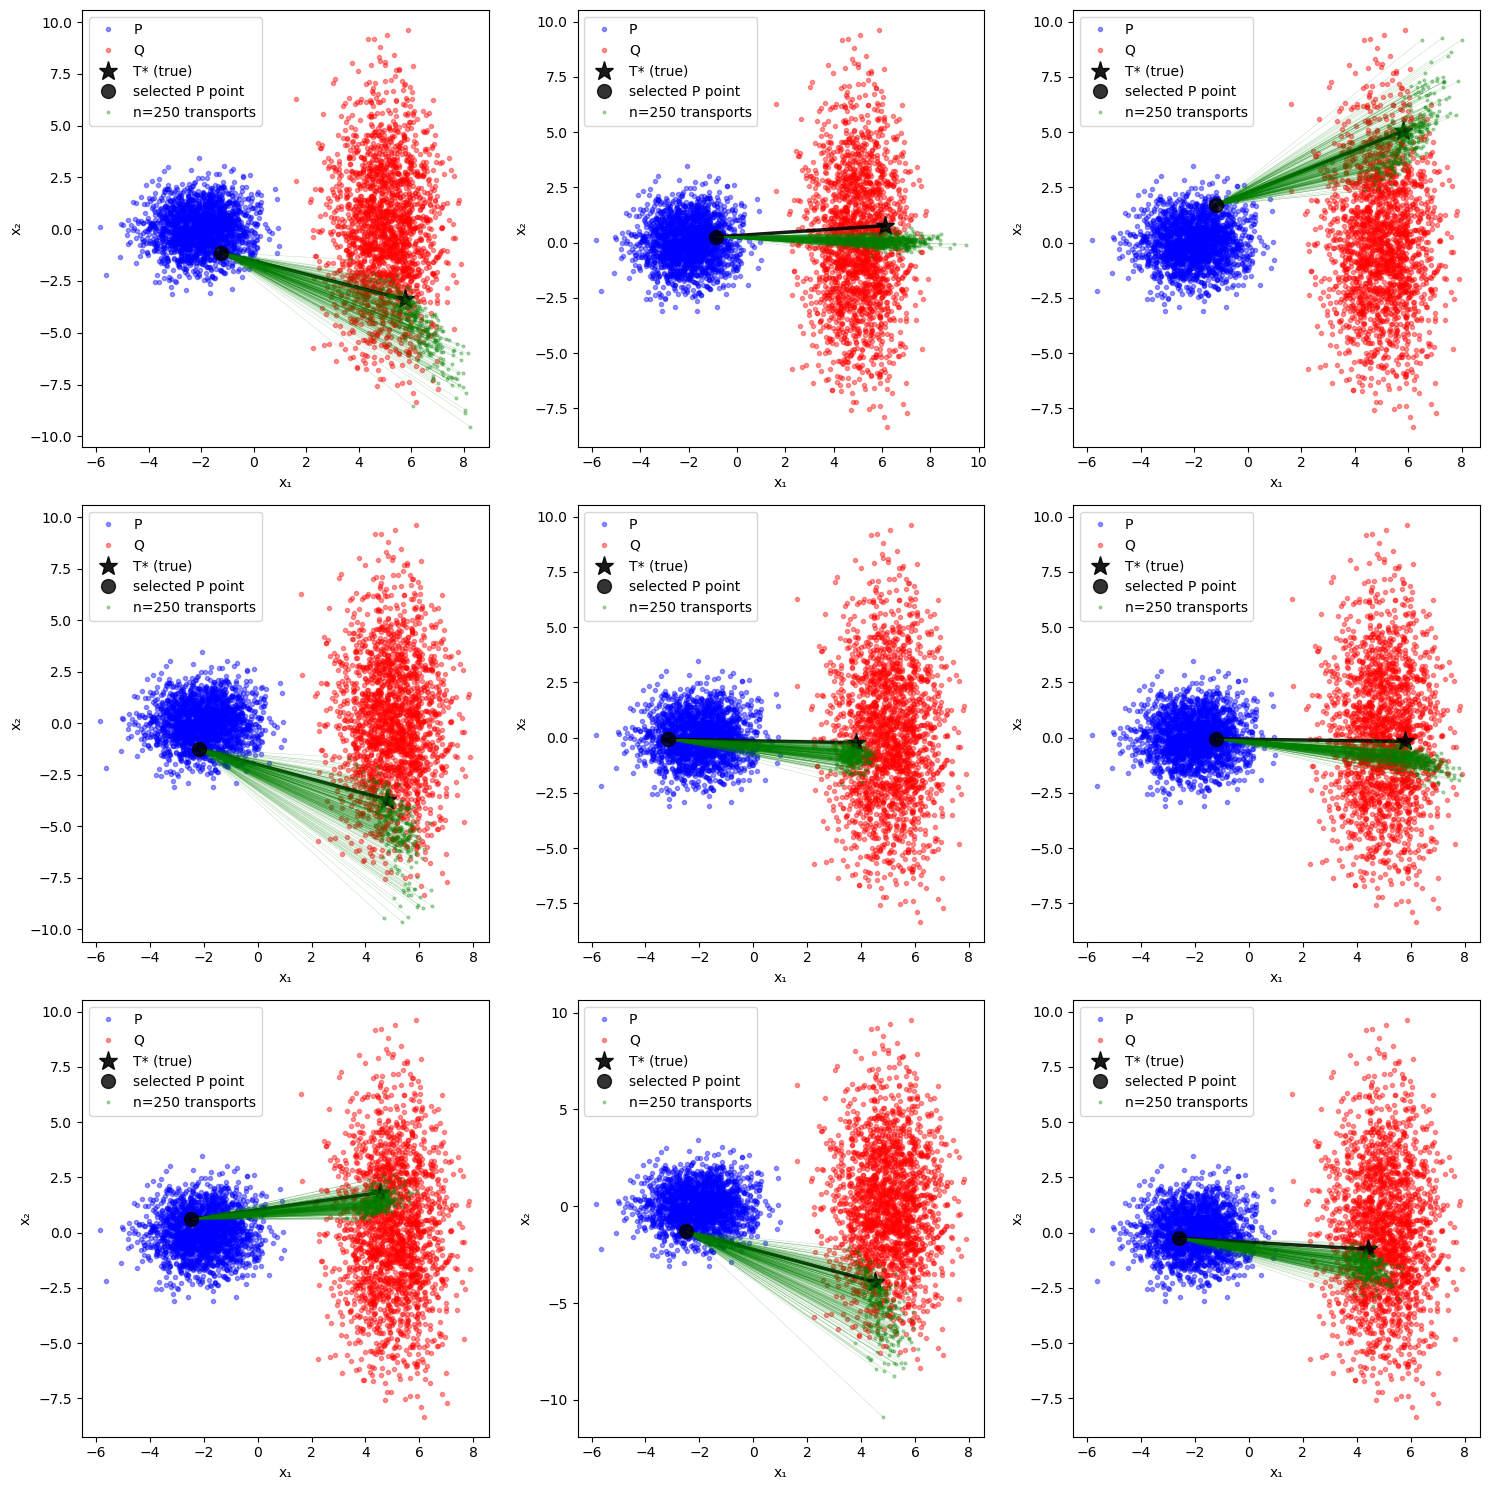

In [106]:
fig, axes = plt.subplots(3,3, figsize=(15, 15))

for ax in axes.flat: 
    # create a single plot showing P,Q,Qhat and the transport lines for a single (random) point in P with n=100 transport lines.
    n_transport_lines = 250
    idx = np.random.randint(0, len(P))
    p_point = P[idx].unsqueeze(0).to(device).requires_grad_(True)

    # Sample n transport maps and get transported locations for the single point
    transported_points = []
    for _ in range(n_transport_lines):
        f_state_dict = f.sample()
        f_base.load_state_dict(f_state_dict)
        qhat_point = x_to_y(f_base, p_point).detach().cpu().numpy()
        transported_points.append(qhat_point)
    transported_points = np.array(transported_points).squeeze(1)  # (n, 2)

    # True optimal transport (T*) for the selected point
    true_dest = optimal_transport_map(P[idx:idx+1]).detach().numpy().squeeze()

    ax.plot(P[:, 0].numpy(), P[:, 1].numpy(), 'b.', alpha=0.4, label='P')
    ax.plot(Q[:, 0].numpy(), Q[:, 1].numpy(), 'r.', alpha=0.4, label='Q')

    p_np = P[idx].numpy()
    # True transport line (T*)
    ax.plot([p_np[0], true_dest[0]], [p_np[1], true_dest[1]], 'k-', lw=2.5, alpha=0.9)
    ax.plot(true_dest[0], true_dest[1], 'k*', markersize=14, alpha=0.9, label='T* (true)')
    for j in range(n_transport_lines):
        ax.plot([p_np[0], transported_points[j, 0]], [p_np[1], transported_points[j, 1]],
                'g-', alpha=0.3, lw=0.3)
    ax.plot(p_np[0], p_np[1], 'ko', markersize=10, label='selected P point', alpha=0.8)
    ax.plot(transported_points[:, 0], transported_points[:, 1], 'g.', alpha=0.3, markersize=4, label=f'n={n_transport_lines} transports')
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')
    ax.legend()

plt.tight_layout()
plt.show() 

## Transport Map Uncertainty Quantification

The HyperNet produces an **ensemble** of transport maps $\{T_z\}$. For each source point $x_i$, we fit a 2-D Gaussian to the ensemble predictions and measure the Mahalanobis distance of the optimal $T^*(x_i)$. Under perfect calibration, $d^2 \sim \chi^2(2)$.

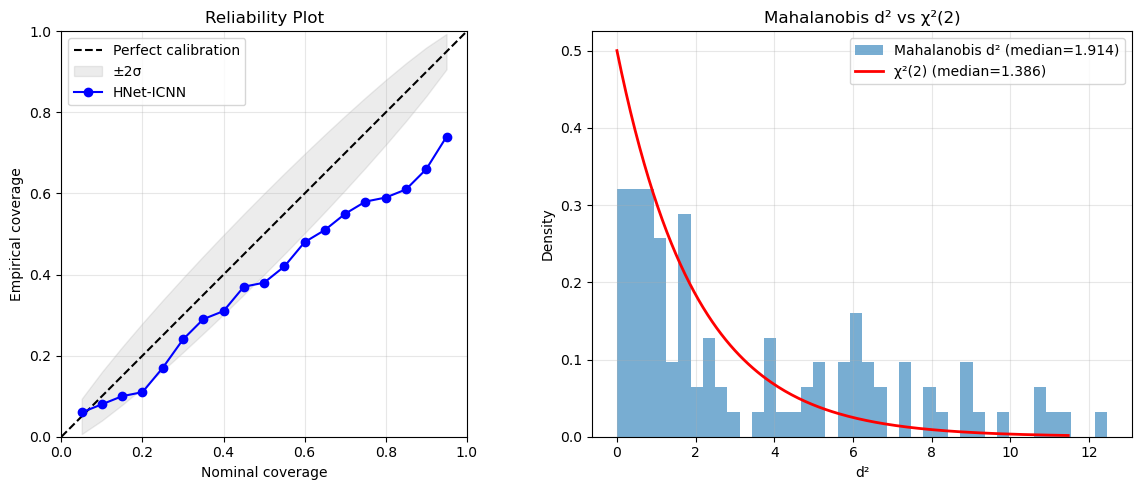

In [105]:
N_SAMPLES = 1000

P_np = P.detach().cpu().numpy()
Q_np = Q.detach().cpu().numpy()

torch.manual_seed(999)
P_test = torch.randn(n_samples, 2) * sigma_P + mu_P
Q_test = (torch.randn(n_samples, 2) * sigma_Q + mu_Q).numpy()
P_test_np = P_test.numpy()

# ------------------------------------


from scipy.stats import chi2

K = 250
n_test = len(P_test)

T_star = optimal_transport_map(P_test).numpy()

preds = np.zeros((K, n_test, 2))
for k in range(K):
    sd = f.sample()
    f_base.load_state_dict(sd)
    preds[k] = x_to_y(f_base.to(device), P_test.to(device).requires_grad_(True)).detach().cpu().numpy()

d = 2
mahal_sq = np.zeros(n_test)
for i in range(n_test):
    samples = preds[:, i, :]
    mu = samples.mean(axis=0)
    cov = np.cov(samples.T) + 1e-6 * np.eye(d)
    diff = T_star[i] - mu
    mahal_sq[i] = diff @ np.linalg.solve(cov, diff)

alphas = np.linspace(0.05, 0.95, 19)
thresholds = chi2.ppf(alphas, df=d)
empirical = np.array([np.mean(mahal_sq <= t) for t in thresholds])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
se = np.sqrt(alphas * (1 - alphas) / n_test)
ax.fill_between(alphas, alphas - 2*se, alphas + 2*se, alpha=0.15, color='gray', label='±2σ')
ax.plot(alphas, empirical, 'bo-', label='HNet-ICNN')
ax.set_xlabel('Nominal coverage')
ax.set_ylabel('Empirical coverage')
ax.set_title('Reliability Plot')
ax.legend()
ax.set_aspect('equal')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

ax = axes[1]
x_chi2 = np.linspace(0, max(8, np.percentile(mahal_sq, 99)), 200)
ax.hist(mahal_sq, bins=40, density=True, alpha=0.6,
        label=f'Mahalanobis d² (median={np.median(mahal_sq):.3f})')
ax.plot(x_chi2, chi2.pdf(x_chi2, df=d), 'r-', lw=2,
        label=f'χ²({d}) (median={chi2.median(df=d):.3f})')
ax.set_xlabel('d²'); ax.set_ylabel('Density')
ax.set_title('Mahalanobis d² vs χ²(2)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Conditional ICNNs for multi-condition optimal transport 

From my experience, one of the limitations of OT via ICNNs is that conditional variables can't be included in the model input.   

For example, [CellOT](https://www.nature.com/articles/s41592-023-01969-x) uses ICNNs to learn mapping from unperturbed cell state to drug-perturbed cell states. Common perturbation datasets contain hundreds to thousands of conditions, however, CellOT requires training individual transport maps within condition. Given that many drugs cause similar perturbations and cell line context is predictive of response, then it's apparent that training a cross condition model (1 model for many conditions) could be very useful. 

Now that we can perform OT with Hypernets(ICNNs), the next question is: Can we use conditional variables in the Hypernet to learn a shared model for multiple transport plans? 

In [74]:
N = 2000

P = torch.distributions.MultivariateNormal(torch.tensor([0.,0.]), torch.tensor([[1.,0.], [0., 1.]]))
Q1 = torch.distributions.MultivariateNormal(torch.tensor([5.,5.]), torch.tensor([[1.,0.], [0., 2.]]))
Q2 = torch.distributions.MultivariateNormal(torch.tensor([-5.,-5.]), torch.tensor([[2.,0.], [0., 1.]]))


P_data = P.sample((N,))
Q1_data = Q1.sample((N,))
Q2_data = Q2.sample((N,))

print('P shape', P_data.shape)

C1 = torch.tensor([[0., 1.]], device=device) # Replace this with one hot if more than 2 conditions
C2 = torch.tensor([[1., 0.]], device=device)

P shape torch.Size([2000, 2])


In [75]:
# update to use conditional variables 
def J_f_g3(f, g, x, y, c, n_samples=10): 
    '''
    Eq (9) from the paper: https://arxiv.org/pdf/1908.10962 ; vectorized for use with hypernets.
    Each sample n uses the SAME (f_n, g_n) pair for all terms.
    # Use jacrev + functional_call per https://discuss.pytorch.org/t/vmap-over-autograd-grad-of-a-nn-module/179038/2

    '''
    x = x.detach().requires_grad_(True)
    y = y.detach().requires_grad_(True)
    c = c.detach().to(x.device, dtype=x.dtype).reshape(-1)

    z = f._sample_z(n_samples).to(x.device)

    def single_loss(z_n, x, y, c):
        f_params = f.sample(C=c, z=z_n)
        g_params = g.sample(C=c, z=z_n)

        fx_n = functional_call(f.model, f_params, x)                  # (B, 1)

        def g_call(y):
            return functional_call(g.model, g_params, y).sum()

        grad_gy_n = jacrev(g_call)(y).squeeze(0)                      # (B, 2)
        f_grad_gy_n = functional_call(f.model, f_params, grad_gy_n)   # (B, 1)
        y_dot_grad_gy_n = (y * grad_gy_n).sum(-1, keepdim=True)       # (B, 1)

        return (f_grad_gy_n - y_dot_grad_gy_n - fx_n).mean()

    J = vmap(single_loss, in_dims=(0, None, None, None))(z, x, y, c).mean()

    return J

In [76]:
f_base = ICNN(dim=2, dimh=256, num_hidden_layers=2).to(device)
g_base = ICNN(dim=2, dimh=256, num_hidden_layers=2).to(device)

pz = 'bernoulli'

f = HyperNet(f_base, stochastic_channels = 64, width=128, pz=pz, bias=True, cond_dim=2).to(device)
g = HyperNet(g_base, stochastic_channels = 64, width=128, pz=pz, bias=True, cond_dim=2).to(device)

optim_f = torch.optim.AdamW(f.parameters(), lr=1e-4, weight_decay=1e-6)
optim_g = torch.optim.AdamW(g.parameters(), lr=1e-4, weight_decay=1e-6)

print(f"f total: {sum(p.numel() for p in f.parameters()):,}")
print(f"g total: {sum(p.numel() for p in g.parameters()):,}")

f total: 8,778,118
g total: 8,778,118


In [ ]:
B = 256
iters = 250 
g_steps = 3
print_every = 25
n_samples = 100
k_mmd = 1

history = {'f_loss': [], 'g_loss': [], 'mmd1': [], 'mmd2': []}

for iter in range(1, iters + 1):
    
    x = sample_x(P_data, B) 

    for ii in range(g_steps): 
        optim_g.zero_grad() 
        y1 = sample_y(Q1_data, B)
        y2 = sample_y(Q2_data, B)
        g_loss = J_f_g3(f,g,x,y1, c=C1,  n_samples=n_samples) # minimize (9)
        g_loss += J_f_g3(f,g,x,y2, c=C2, n_samples=n_samples) # minimize (9)
        g_loss.backward()
        optim_g.step()

    optim_f.zero_grad()
    f_loss = -J_f_g3(f,g,x,y1, c=C1, n_samples=n_samples) # maximize (9)
    f_loss += -J_f_g3(f,g,x,y2, c=C2, n_samples=n_samples) # maximize (9)
    f_loss.backward()
    optim_f.step()

    # eval
    mmd1 = 0
    for _ in range(k_mmd): 
        sd = f.sample(C=C1) # sample a function
        f_base.load_state_dict(sd)
        yhat = x_to_y(f_base, P_data.to(device).requires_grad_(True))
        mmd1 += mmd_rbf(Q1_data.detach().cpu().numpy(), yhat.detach().cpu().numpy())
    mmd1 /= k_mmd

    # eval
    mmd2 = 0
    for _ in range(k_mmd): 
        sd = f.sample(C=C2) # sample a function
        f_base.load_state_dict(sd)
        yhat = x_to_y(f_base, P_data.to(device).requires_grad_(True))
        mmd2 += mmd_rbf(Q2_data.detach().cpu().numpy(), yhat.detach().cpu().numpy())
    mmd2 /= k_mmd

    history['f_loss'].append(f_loss.item())
    history['g_loss'].append(g_loss.item())
    history['mmd1'].append(mmd1)
    history['mmd2'].append(mmd2)

    if (iter % print_every) == 0: 
        print(f'Iteration {iter}, f_loss {f_loss.item():.2f}, g_loss {g_loss.item():.2f}, mmd1: {np.mean(history['mmd1'][-print_every:]):.4f}, mmd2: {np.mean(history['mmd2'][-print_every:]):.4f}')
        

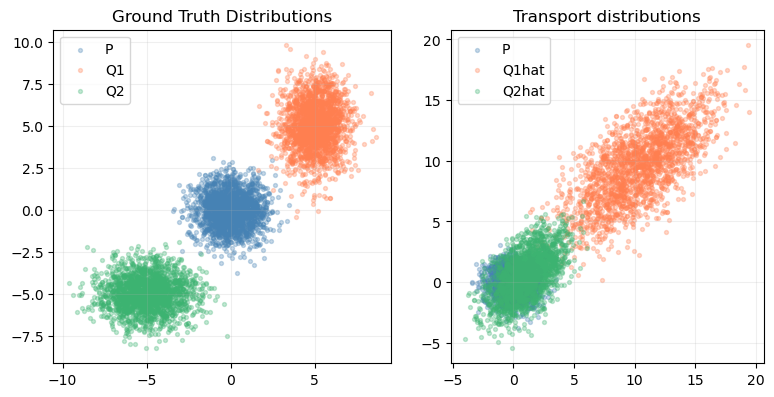

In [ ]:
n_transport_samples = 1

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

P_np = P_data.numpy()
Q1_np = Q1_data.numpy()
Q2_np = Q2_data.numpy()

sd1 = f.sample(C=C1)
f_base.load_state_dict(sd1)
Q1hat_np = x_to_y(f_base.cuda(), P_data.cuda().requires_grad_(True)).detach().cpu().numpy()

sd2 = f.sample(C=C2)
f_base.load_state_dict(sd2)
Q2hat_np = x_to_y(f_base.cuda(), P_data.cuda().requires_grad_(True)).detach().cpu().numpy()

# Ground truth distributions
ax = axes[0]
ax.scatter(P_np[:, 0], P_np[:, 1], c='steelblue', alpha=0.3, s=8, label='P')
ax.scatter(Q1_np[:, 0], Q1_np[:, 1], c='coral', alpha=0.3, s=8, label='Q1')
ax.scatter(Q2_np[:, 0], Q2_np[:, 1], c='mediumseagreen', alpha=0.3, s=8, label='Q2')
ax.set_title('Ground Truth Distributions')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)

ax = axes[1]
ax.scatter(P_np[:, 0], P_np[:, 1], c='steelblue', alpha=0.3, s=8, label='P')
ax.scatter(Q1hat_np[:, 0], Q1hat_np[:, 1], c='coral', alpha=0.3, s=8, label='Q1hat')
ax.scatter(Q2hat_np[:, 0], Q2hat_np[:, 1], c='mediumseagreen', alpha=0.3, s=8, label='Q2hat')
ax.set_title('Transport distributions')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()